# Collect — teacher decisions across different worlds

**Goal.** Record the hardcoded `RuleBrain`'s `(perception → action)` decisions so a neural
network can later *imitate* them (behavioural cloning). We run the **real** `Simulation`
unchanged, wrap its brain so every alive animal's decision is captured, and do it across
**several different worlds** so the clone learns behaviour, not one map.

**No memory (yet).** This first pass has no LSTM, so a decision depends only on the *current*
observation — every captured row is an independent training example and we need no
`birth_id` / recurrent bookkeeping.

**What a row is.** Perception = egocentric grids `(C, K, K)` (K=57 here) + a `(10,)` scalar
vector — exactly what `Brain.decide` sees. The target is the RuleBrain's 6-D action
`[dx, dy, eat, drink, repro, speed]`. Grids are big (~16k floats/row for sheep), so we store
each species in a compressed **`.npz`** (float16 grids) rather than a multi-GB CSV.

Uniform **reservoir sampling** keeps a fixed number of rows per world spread evenly across
the whole recording window (not front-loaded), with bounded memory.

In [1]:
import sys
from pathlib import Path
_cwd = Path.cwd()                             # make common.py importable from either cwd
for _c in (_cwd, _cwd / "notebooks" / "imitation_learning"):
    if (_c / "common.py").exists():
        sys.path.insert(0, str(_c)); break
import numpy as np
import matplotlib.pyplot as plt
import common as C
from config import SHEEP, FOX, SPECIES_NAMES

print("repo:", C.REPO)
print("datasets ->", {SPECIES_NAMES[s]: C.DATA_PATHS[s].name for s in C.SPECIES_IDS})

repo: c:\Users\afree\Desktop\ecosystem
datasets -> {'sheep': 'sheep.npz', 'fox': 'fox.npz'}


## Parameters

`WORLD_SEEDS` are the distinct maps we sample from (terrain + rivers differ per seed).
`WARMUP` lets the founder seeding relax into natural predator–prey dynamics before we record.
`PER_WORLD` is how many rows to keep per species **per world** — an equal share from each map.
Foxes are far rarer than sheep, so they get a smaller quota.

In [4]:
# WORLD_SEEDS = [12345, 7, 99, 2024, 555, 31337]   # six different worlds
WORLD_SEEDS = range(30)   # six different worlds
WARMUP       = 100      # ticks to settle before recording
RECORD_TICKS = 500      # max ticks recorded per world (stops early once quotas fill)
PER_WORLD    = {SHEEP: 6000, FOX: 3000}          # rows kept per species per world

n_worlds = len(WORLD_SEEDS)
print(f"{n_worlds} worlds -> up to "
      f"{n_worlds*PER_WORLD[SHEEP]} sheep + {n_worlds*PER_WORLD[FOX]} fox rows")

30 worlds -> up to 180000 sheep + 90000 fox rows


## Collect

For each world: build the `Simulation` with the RuleBrain teacher, warm up, then record a
uniform sample of its decisions. Populations after warm-up are printed per world.

In [5]:
data = C.collect_dataset(WORLD_SEEDS, PER_WORLD,
                         warmup=WARMUP, record_ticks=RECORD_TICKS)

for sid in C.SPECIES_IDS:
    d = data[sid]
    path = C.save_dataset(sid, d)
    mb = path.stat().st_size / 1e6
    print(f"{SPECIES_NAMES[sid]:>5}: {d['grids'].shape[0]:>6} rows, "
          f"grids {d['grids'].shape[1:]}  ->  {path.name} ({mb:.1f} MB)")

  world 0: pops {'sheep': 293, 'fox': 30}  ->  rows {'sheep': 6000, 'fox': 3000}
  world 1: pops {'sheep': 307, 'fox': 27}  ->  rows {'sheep': 6000, 'fox': 3000}
  world 2: pops {'sheep': 326, 'fox': 22}  ->  rows {'sheep': 6000, 'fox': 3000}
  world 3: pops {'sheep': 236, 'fox': 26}  ->  rows {'sheep': 6000, 'fox': 3000}
  world 4: pops {'sheep': 182, 'fox': 26}  ->  rows {'sheep': 6000, 'fox': 3000}
  world 5: pops {'sheep': 241, 'fox': 28}  ->  rows {'sheep': 6000, 'fox': 3000}
  world 6: pops {'sheep': 303, 'fox': 24}  ->  rows {'sheep': 6000, 'fox': 3000}
  world 7: pops {'sheep': 194, 'fox': 28}  ->  rows {'sheep': 6000, 'fox': 3000}
  world 8: pops {'sheep': 227, 'fox': 25}  ->  rows {'sheep': 6000, 'fox': 3000}
  world 9: pops {'sheep': 231, 'fox': 26}  ->  rows {'sheep': 6000, 'fox': 3000}
  world 10: pops {'sheep': 285, 'fox': 27}  ->  rows {'sheep': 6000, 'fox': 3000}
  world 11: pops {'sheep': 182, 'fox': 25}  ->  rows {'sheep': 6000, 'fox': 3000}
  world 12: pops {'sheep':

## Sanity check

Reload each dataset and look at the target distribution — what fraction of the time the
teacher raises each gate, and how the headings are spread. Then visualize one sheep's raw
perception channels: the network sees exactly these.

In [6]:
for sid in C.SPECIES_IDS:
    d = C.load_dataset(sid)
    a = d["actions"]
    print(f"{SPECIES_NAMES[sid]:>5}: eat={a[:,2].mean():.2f} drink={a[:,3].mean():.2f} "
          f"repro={a[:,4].mean():.2f} speed={a[:,5].mean():.2f} | "
          f"worlds {np.bincount(d['world'])}")

sheep: eat=0.58 drink=0.17 repro=0.41 speed=0.43 | worlds [6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000
 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000
 6000 6000]
  fox: eat=0.07 drink=0.21 repro=0.45 speed=0.43 | worlds [3000 3000 3000 3000 3000 3000 3000 3000 3000 3000 3000 3000 3000 3000
 3000 3000 3000 3000 3000 3000 3000 3000 3000 3000 3000 3000 3000 3000
 3000 3000]


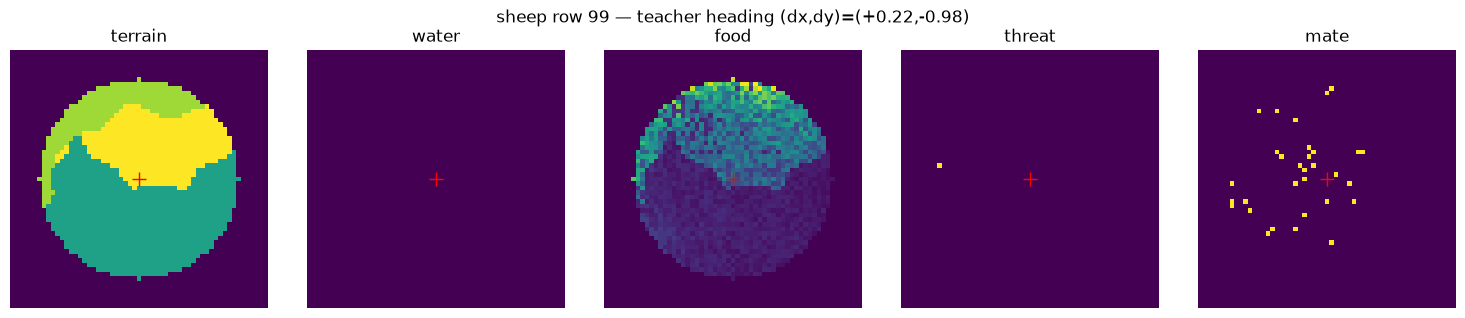

In [7]:
from sim.perception import CHANNEL_NAMES
d = C.load_dataset(SHEEP)
i = int(np.argmax((d['grids'][:, 2] > 0).reshape(d['grids'].shape[0], -1).sum(1)))  # food-rich view
grids = d['grids'][i].astype(np.float32)
names = CHANNEL_NAMES[SHEEP]
fig, ax = plt.subplots(1, len(names), figsize=(3*len(names), 3.2))
for c, name in enumerate(names):
    ax[c].imshow(grids[c], origin="upper", cmap="viridis")
    ax[c].plot(grids.shape[-1]//2, grids.shape[-2]//2, "r+", ms=10)   # agent at centre
    ax[c].set_title(name); ax[c].axis("off")
dx, dy, *_ = d['actions'][i]
fig.suptitle(f"sheep row {i} — teacher heading (dx,dy)=({dx:+.2f},{dy:+.2f})")
plt.tight_layout(); plt.show()

Datasets written to `sheep.npz` / `fox.npz`. Next: **`train_sheep.ipynb`** and
**`train_fox.ipynb`** clone each teacher into a memoryless CNN+MLP policy.